# Coastal Groundwater Level Prediction — Climate Scenario Analysis

This notebook predicts future groundwater levels under two IPCC climate scenarios
using the Random Forest model trained in `01_model_training.ipynb`.

| Scenario | Emissions pathway | Projection period |
|---|---|---|
| SSP2-4.5 | Moderate | 2080–2099 vs 1986–2005 baseline |
| SSP5-8.5 | High     | 2080–2099 vs 1986–2005 baseline |

Precipitation change (% relative to baseline) is sampled from CCAM-downscaled
NZ5km climate projections. All other predictors are held constant so that
\u0394GWL reflects the rainfall-driven signal only.

**Prerequisites:** run `01_model_training.ipynb` first to produce
`rf_groundwater_model.joblib`.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import joblib

from utils import add_pr_change_to_points

In [ ]:
# ── Paths (update DATA_DIR to point at your local data folder) ───────────────
DATA_DIR   = "data"
GRID_CSV   = f"{DATA_DIR}/modelGrid_March2025.csv"
MODEL_PATH = "rf_groundwater_model.joblib"

NC_SSP245  = f"{DATA_DIR}/PR_ssp245_MMM_CCAM_change_fp2080-2099_bp1986-2005_ANN_NZ5km.nc"
NC_SSP585  = f"{DATA_DIR}/PR_ssp585_MMM_CCAM_change_fp2080-2099_bp1986-2005_ANN_NZ5km.nc"

OUT_SSP245 = f"{DATA_DIR}/Predicted_GWL_ssp245.csv"
OUT_SSP585 = f"{DATA_DIR}/Predicted_GWL_ssp585.csv"

# ── Features (must match 01_model_training.ipynb) ────────────────────────────
FEATURES = [
    "SoilType", "SoilDrain", "GeolAge", "MainRock",
    "FlowFRE3", "FlowMALF", "RainFall",
    "easting", "northing", "closest_coastal_distance", "ground_elevation",
]

# ── PR sampling parameters ────────────────────────────────────────────────────
MAX_FILL_DIST_M = 15_000  # max snap distance for coastal-edge NaN fill (metres)

## 1. Load and Preprocess Model Grid

In [3]:
grid = pd.read_csv(GRID_CSV)
grid = grid.rename(columns={
    "Rainfall":   "RainFall",
    "Easting":    "easting",
    "Northing":   "northing",
    "ground_ele": "ground_elevation",
    "distance_t": "closest_coastal_distance",
})
grid["closest_coastal_distance"] = grid["closest_coastal_distance"] / 1000
grid["MainRock"] = grid["MainRock"].astype(int)
grid.drop(columns=["FID", "Shape"], inplace=True)
grid.replace(-9999, np.nan, inplace=True)
grid.dropna(inplace=True)

print(f"Model grid: {len(grid):,} points")
grid.head()

Model grid: 473,984 points


,easting,northing,SoilType,MainRock,GeolAge,SubRock,FlowMALF,FlowFRE3,SoilDrain,RainFall,closest_coastal_distance,ground_elevation
0,1600658,6193727,5,3,101.0,3.0,0.00000,0.000000,3,1014.000000,0.315592,203.24
1,1600908,6193727,5,3,101.0,3.0,-7.03284,13.091878,3,1011.099976,0.378551,203.88
2,1601158,6193727,5,3,101.0,3.0,-7.03284,13.091878,3,1011.099976,0.447847,197.45
3,1601408,6193727,5,3,101.0,3.0,-7.03284,13.091878,3,1008.700012,0.426442,197.52
4,1601658,6193727,5,3,101.0,3.0,0.00000,0.000000,3,1008.700012,0.324091,198.15


## 2. Sample Precipitation Change from Climate Scenarios

The CCAM NetCDF files contain the projected percentage change in annual
precipitation on a 5 km WGS84 grid. Each model-grid point is assigned
the nearest valid cell value. Coastal points outside the grid extent
are filled by snapping to the nearest valid cell within 15 km.

In [4]:
ds_ssp245 = xr.open_dataset(NC_SSP245, engine="netcdf4")

grid_ssp245 = add_pr_change_to_points(
    ds_ssp245, grid,
    out_col="PR_change_pct",
    fill_missing=True,
    max_dist_m=MAX_FILL_DIST_M,
)

n_miss = int(grid_ssp245["PR_change_pct"].isna().sum())
print(f"SSP2-4.5 \u2014 still missing after fill: {n_miss:,}/{len(grid_ssp245):,}")

grid_ssp245["rainfall_ssp245"] = (
    grid_ssp245["RainFall"] * (1 + grid_ssp245["PR_change_pct"] / 100)
)
grid_ssp245.dropna(subset=["rainfall_ssp245"], inplace=True)

print(f"Mean baseline rainfall : {grid_ssp245['RainFall'].mean():.1f} mm/yr")
print(f"Mean SSP2-4.5 rainfall : {grid_ssp245['rainfall_ssp245'].mean():.1f} mm/yr")

SSP2-4.5 — still missing after fill: 50/473,984
Mean baseline rainfall : 1519.4 mm/yr
Mean SSP2-4.5 rainfall : 1531.4 mm/yr


In [5]:
ds_ssp585 = xr.open_dataset(NC_SSP585, engine="netcdf4")

grid_ssp585 = add_pr_change_to_points(
    ds_ssp585, grid,
    out_col="PR_change_pct",
    fill_missing=True,
    max_dist_m=MAX_FILL_DIST_M,
)

n_miss = int(grid_ssp585["PR_change_pct"].isna().sum())
print(f"SSP5-8.5 \u2014 still missing after fill: {n_miss:,}/{len(grid_ssp585):,}")

grid_ssp585["rainfall_ssp585"] = (
    grid_ssp585["RainFall"] * (1 + grid_ssp585["PR_change_pct"] / 100)
)
grid_ssp585.dropna(subset=["rainfall_ssp585"], inplace=True)

print(f"Mean baseline rainfall : {grid_ssp585['RainFall'].mean():.1f} mm/yr")
print(f"Mean SSP5-8.5 rainfall : {grid_ssp585['rainfall_ssp585'].mean():.1f} mm/yr")

SSP5-8.5 — still missing after fill: 50/473,984
Mean baseline rainfall : 1519.4 mm/yr
Mean SSP5-8.5 rainfall : 1531.9 mm/yr


## 3. Groundwater Level Predictions under Climate Scenarios

The model is applied twice per scenario:
1. **Baseline** — current observed rainfall, producing a reference GWL.
2. **Future** — projected future rainfall replacing `RainFall`, all other
   predictors unchanged.

The difference (\u0394GWL = future \u2212 baseline) isolates the rainfall-driven signal.

In [6]:
model = joblib.load(MODEL_PATH)
print(f"Model loaded from: {MODEL_PATH}")

Model loaded from: rf_groundwater_model.joblib


In [7]:
X_base_245 = grid_ssp245[FEATURES].copy()
X_fut_245  = X_base_245.copy()
X_fut_245["RainFall"] = grid_ssp245["rainfall_ssp245"].to_numpy()

grid_ssp245["pred_GWL_baseline"] = model.predict(X_base_245)
grid_ssp245["pred_GWL_ssp245"]   = model.predict(X_fut_245)
grid_ssp245["delta_GWL_ssp245"]  = (
    grid_ssp245["pred_GWL_ssp245"] - grid_ssp245["pred_GWL_baseline"]
)

print("SSP2-4.5 \u0394 GWL (m):")
print(grid_ssp245["delta_GWL_ssp245"].describe().round(4))

SSP2-4.5 Δ GWL (m):
count    473934.0000
mean         -0.0325
std           0.7424
min         -17.7962
25%          -0.0356
50%           0.0000
75%           0.0166
max          16.6308
Name: delta_GWL_ssp245, dtype: float64


In [8]:
X_base_585 = grid_ssp585[FEATURES].copy()
X_fut_585  = X_base_585.copy()
X_fut_585["RainFall"] = grid_ssp585["rainfall_ssp585"].to_numpy()

grid_ssp585["pred_GWL_baseline"] = model.predict(X_base_585)
grid_ssp585["pred_GWL_ssp585"]   = model.predict(X_fut_585)
grid_ssp585["delta_GWL_ssp585"]  = (
    grid_ssp585["pred_GWL_ssp585"] - grid_ssp585["pred_GWL_baseline"]
)

print("SSP5-8.5 \u0394 GWL (m):")
print(grid_ssp585["delta_GWL_ssp585"].describe().round(4))

SSP5-8.5 Δ GWL (m):
count    473934.0000
mean         -0.0346
std           0.9863
min         -25.8470
25%          -0.0704
50%           0.0000
75%           0.0297
max          18.1574
Name: delta_GWL_ssp585, dtype: float64


In [9]:
grid_ssp245.to_csv(OUT_SSP245, index=False)
grid_ssp585.to_csv(OUT_SSP585, index=False)

print(f"SSP2-4.5 predictions saved \u2192 {OUT_SSP245}")
print(f"SSP5-8.5 predictions saved \u2192 {OUT_SSP585}")

SSP2-4.5 predictions saved → /home/rqiu/Documents/Groundwater_modelling/data/Predicted_GWL_ssp245.csv
SSP5-8.5 predictions saved → /home/rqiu/Documents/Groundwater_modelling/data/Predicted_GWL_ssp585.csv


## 4. Summary Statistics

In [10]:
scenarios = {
    "SSP2-4.5": grid_ssp245["delta_GWL_ssp245"],
    "SSP5-8.5": grid_ssp585["delta_GWL_ssp585"],
}

rows = []
for name, delta in scenarios.items():
    rows.append({
        "Scenario":              name,
        "Mean \u0394GWL (m)":    round(float(delta.mean()), 4),
        "Median \u0394GWL (m)":  round(float(delta.median()), 4),
        "Std (m)":               round(float(delta.std()), 4),
        "5th pct (m)":           round(float(delta.quantile(0.05)), 4),
        "95th pct (m)":          round(float(delta.quantile(0.95)), 4),
        "% points GWL rise":     round(float((delta > 0).mean() * 100), 2),
    })

pd.DataFrame(rows).set_index("Scenario")

,Mean ΔGWL (m),Median ΔGWL (m),Std (m),5th pct (m),95th pct (m),% points GWL rise
Scenario,,,,,,
SSP2-4.5,-0.0325,0.0,0.7424,-0.3200,0.2382,36.04
SSP5-8.5,-0.0346,0.0,0.9863,-0.5447,0.4192,37.35


### Distribution of \u0394GWL across all grid points

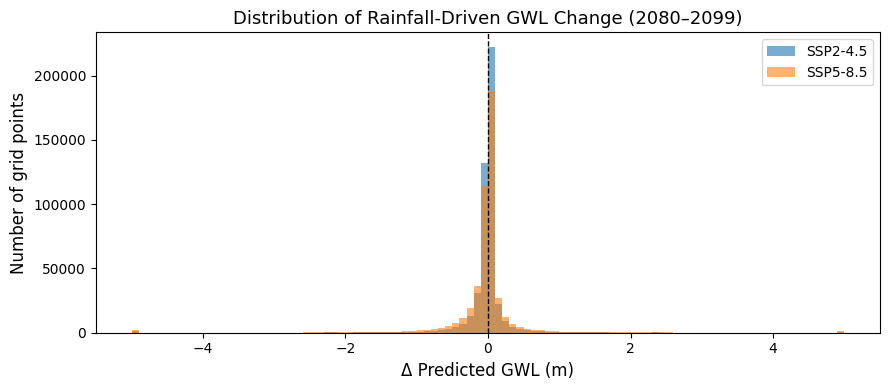

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))

for name, delta in scenarios.items():
    ax.hist(delta.clip(-5, 5), bins=100, alpha=0.6, label=name)

ax.axvline(0, color="black", lw=1, linestyle="--")
ax.set_xlabel("\u0394 Predicted GWL (m)", fontsize=12)
ax.set_ylabel("Number of grid points", fontsize=12)
ax.set_title("Distribution of Rainfall-Driven GWL Change (2080\u20132099)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()